# 🧩 Notebook 07: Module 5 — Clustering
## Graph-Based MST, Model-Based EM/GMM, Density-Based DBSCAN & Zero-Day Detection

In [6]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from src.utils import load_numpy, save_model, load_model
from src.clustering_models import (
    train_mst_clustering,
    train_gmm,
    train_dbscan,
    compute_k_distance,
    compute_clustering_metrics
)

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
y_train_multi = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_multi.npy"))
le_multi = load_model(os.path.join(PROJECT_ROOT, "models", "encoders", "label_encoder_multi.pkl"))
class_names = list(le_multi.classes_)

sub_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sub = X_train[sub_idx]
y_sub = y_train_multi[sub_idx]

pca_2d = PCA(n_components=2, random_state=42)
X_sub_pca = pca_2d.fit_transform(X_sub)

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_multi.npy | Shape: (125973,)
📂 Model loaded: d:\WebDev\Network_Intrusion_Detection\models\encoders\label_encoder_multi.pkl


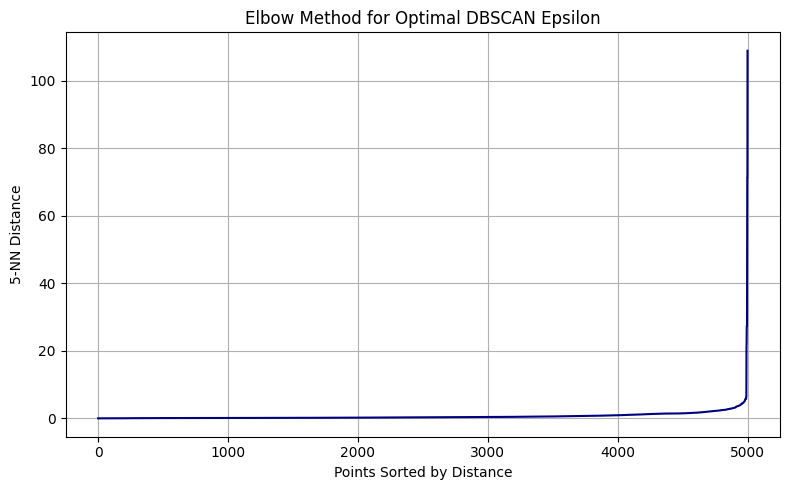

In [7]:
k_distances = compute_k_distance(X_sub, k=5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances, color="navy")
ax.set_xlabel("Points Sorted by Distance")
ax.set_ylabel("5-NN Distance")
ax.set_title("Elbow Method for Optimal DBSCAN Epsilon")
ax.grid(True)
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module5", "elbow_method.png"), dpi=150)
plt.show()

In [8]:
mst_labels = train_mst_clustering(X_sub_pca, n_clusters=5)
mst_metrics = compute_clustering_metrics(X_sub_pca, y_sub, mst_labels)

gmm_model, gmm_labels = train_gmm(X_sub, n_components=5)
gmm_metrics = compute_clustering_metrics(X_sub, y_sub, gmm_labels)
save_model(gmm_model, os.path.join(PROJECT_ROOT, "models", "saved_models", "em_gmm_model.pkl"))

optimal_eps = float(np.percentile(k_distances, 90))
dbscan_model, dbscan_labels = train_dbscan(X_sub, eps=optimal_eps, min_samples=5)
dbscan_metrics = compute_clustering_metrics(X_sub, y_sub, dbscan_labels)
save_model(dbscan_model, os.path.join(PROJECT_ROOT, "models", "saved_models", "dbscan_model.pkl"))

cluster_summary = pd.DataFrame([mst_metrics, gmm_metrics, dbscan_metrics], index=["MST Clustering", "EM / GMM", "DBSCAN"])
print(cluster_summary)
cluster_summary.to_csv(os.path.join(PROJECT_ROOT, "results", "clustering_evaluation.csv"))

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\em_gmm_model.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\dbscan_model.pkl
                     ari       nmi  silhouette  n_clusters  n_noise
MST Clustering  0.003982  0.008884    0.062267           5        0
EM / GMM        0.347161  0.359094    0.310436           5        0
DBSCAN          0.567107  0.592838    0.468398          38      401


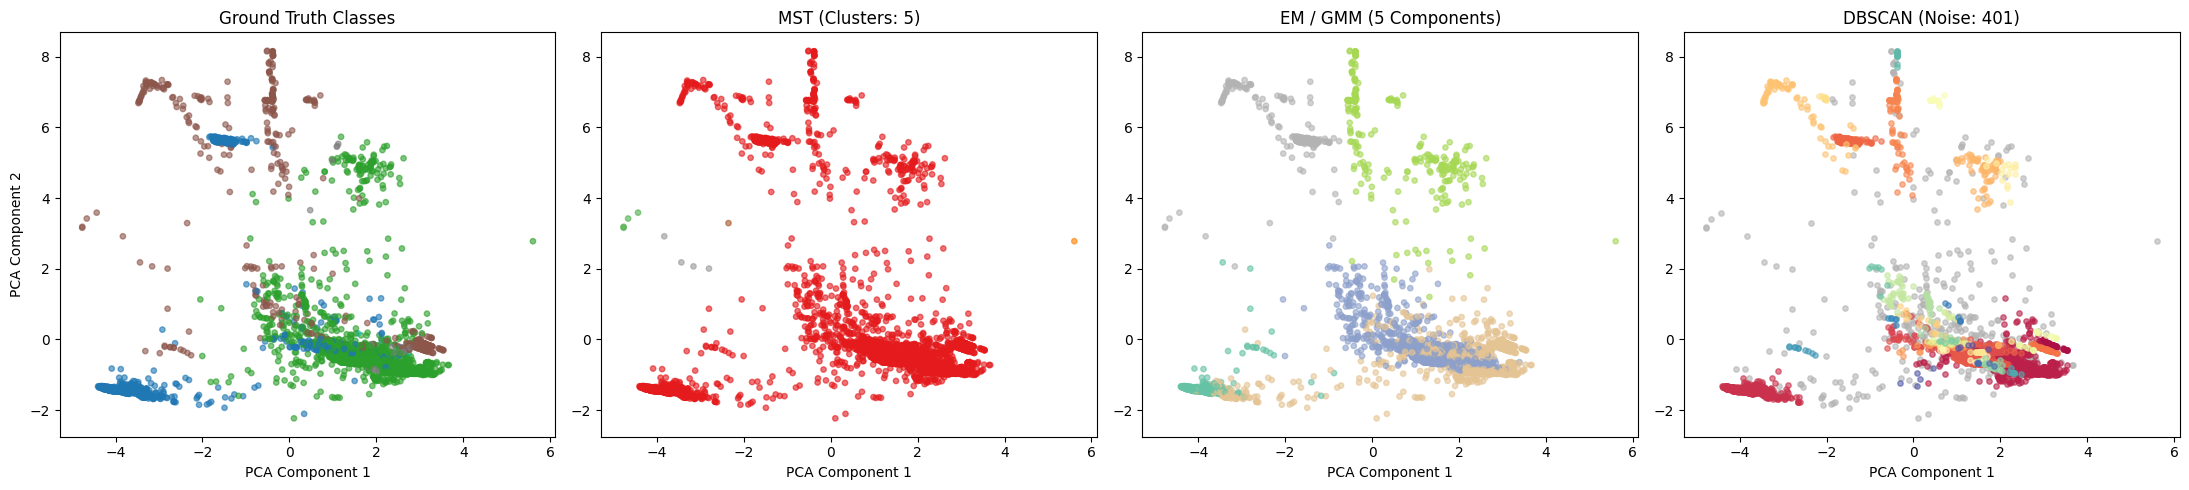

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].scatter(X_sub_pca[:, 0], X_sub_pca[:, 1], c=y_sub, cmap="tab10", s=15, alpha=0.6)
axes[0].set_title("Ground Truth Classes")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

axes[1].scatter(X_sub_pca[:, 0], X_sub_pca[:, 1], c=mst_labels, cmap="Set1", s=15, alpha=0.6)
axes[1].set_title(f"MST (Clusters: {len(np.unique(mst_labels))})")
axes[1].set_xlabel("PCA Component 1")

axes[2].scatter(X_sub_pca[:, 0], X_sub_pca[:, 1], c=gmm_labels, cmap="Set2", s=15, alpha=0.6)
axes[2].set_title("EM / GMM (5 Components)")
axes[2].set_xlabel("PCA Component 1")

unique_db = np.unique(dbscan_labels)
colors_db = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_db))]
for k, col in zip(unique_db, colors_db):
    if k == -1:
        col = [0.7, 0.7, 0.7, 1.0]
    class_member_mask = (dbscan_labels == k)
    xy = X_sub_pca[class_member_mask]
    axes[3].scatter(xy[:, 0], xy[:, 1], color=tuple(col), s=15, alpha=0.6)
axes[3].set_title(f"DBSCAN (Noise: {np.sum(dbscan_labels == -1)})")
axes[3].set_xlabel("PCA Component 1")

plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module5", "dbscan_vs_em_comparison.png"), dpi=150)
plt.show()

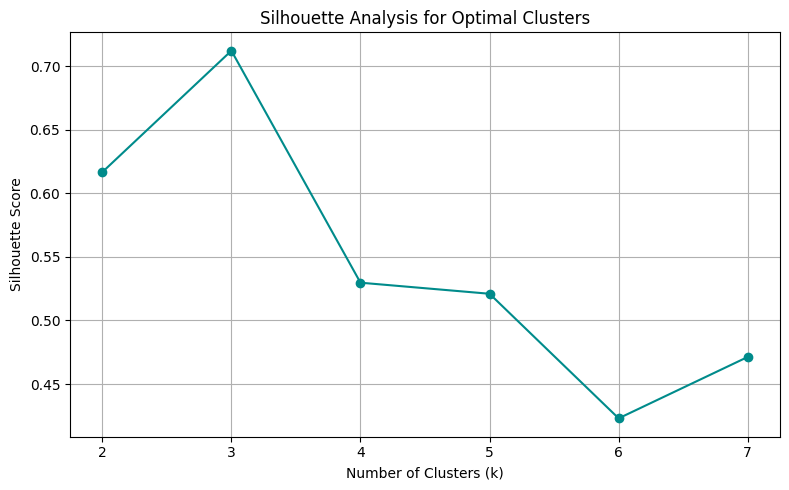

In [10]:
k_range = range(2, 8)
sil_scores = []

for k in k_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    preds = gmm_temp.fit_predict(X_sub_pca)
    sil_scores.append(silhouette_score(X_sub_pca, preds))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, sil_scores, marker="o", color="darkcyan")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Analysis for Optimal Clusters")
ax.grid(True)
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module5", "silhouette_analysis.png"), dpi=150)
plt.show()

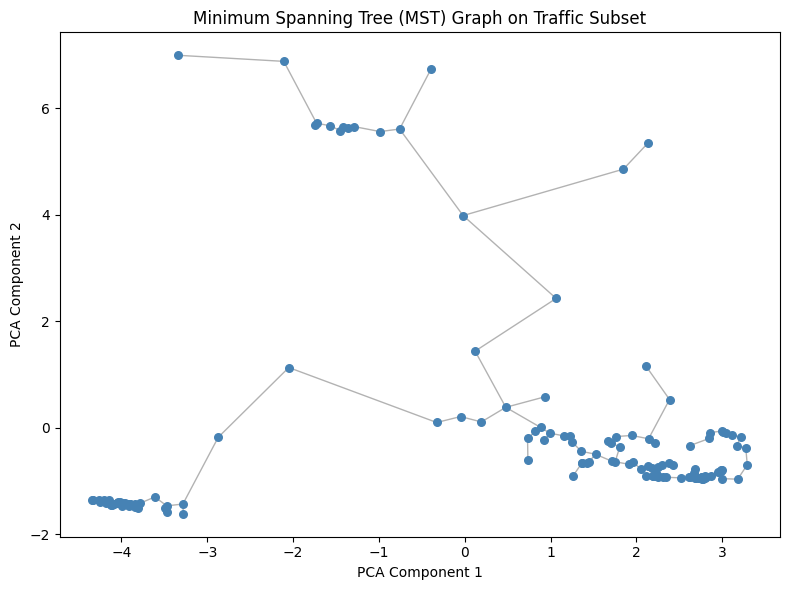

In [11]:
dist_matrix = squareform(pdist(X_sub_pca[:150], metric="euclidean"))
mst = minimum_spanning_tree(dist_matrix).toarray()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_sub_pca[:150, 0], X_sub_pca[:150, 1], c="steelblue", s=30, zorder=3)

rows, cols = np.nonzero(mst)
for r, c in zip(rows, cols):
    ax.plot([X_sub_pca[r, 0], X_sub_pca[c, 0]], [X_sub_pca[r, 1], X_sub_pca[c, 1]], color="gray", alpha=0.6, linewidth=1, zorder=2)

ax.set_title("Minimum Spanning Tree (MST) Graph on Traffic Subset")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module5", "mst_clustering.png"), dpi=150)
plt.show()

        Count  Percentage
normal    268   66.832918
probe      71   17.705736
dos        51   12.718204
r2l         9    2.244389
u2r         2    0.498753


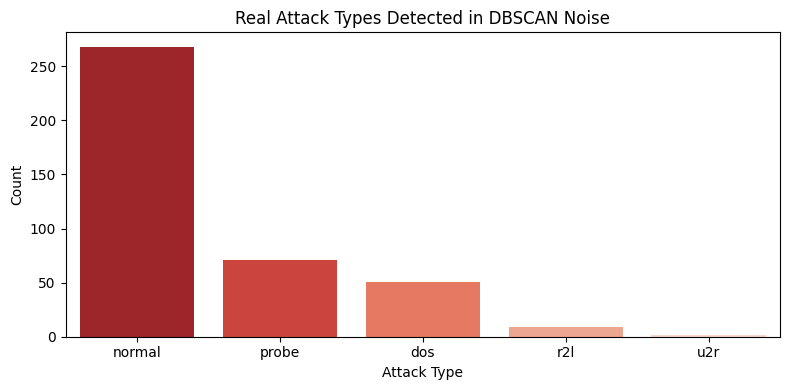

In [12]:
noise_mask = (dbscan_labels == -1)
noise_true_indices = y_sub[noise_mask]
noise_names = [class_names[i] for i in noise_true_indices]

noise_counts = pd.Series(noise_names).value_counts()
noise_df = pd.DataFrame({"Count": noise_counts})
noise_df["Percentage"] = (noise_df["Count"] / noise_df["Count"].sum()) * 100

print(noise_df)
noise_df.to_csv(os.path.join(PROJECT_ROOT, "results", "zero_day_noise_analysis.csv"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=noise_df.index, y=noise_df["Count"], palette="Reds_r", ax=ax)
ax.set_title("Real Attack Types Detected in DBSCAN Noise")
ax.set_ylabel("Count")
ax.set_xlabel("Attack Type")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module5", "zero_day_noise.png"), dpi=150)
plt.show()